# Pulse / Amin replication: Preprocessing and Extraction pipeline

This follows the pipeline described in the project README.

**Input:** [MoltBook Observatory](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

**Output:** Personae, as a set of .txt containing the most representative posts for each cluster.

**Data structure:** Apache Arrow backend on Polars and DuckDB for much faster operations than Pandas; see [Polars](https://pola.rs/).

## Setup

### Libraries

Go to project root, then run ```uv init && uv sync``` to get these installed. 

Use uv, not conda or pip.

**ADD YOUR UV ENV NAME TO .GITIGNORE.**

In [1]:
from dotenv import load_dotenv
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from fast_langdetect import detect as langdetect
from matplotlib.patches import Patch
import matplotlib.lines as mlines
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
import torch
from cuml.metrics.cluster import silhouette_score
import pyarrow as pa
import pyarrow.ipc as pa_ipc
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import duckdb
import pathlib
import datetime
import hashlib
import json
import uuid
import nltk
import os
import cuml
import cuml.manifold
import cupy as cp
import cohere
import json
import asyncio

/home/kiyan/projects/Pulse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Environment variables:

Duplicate ```TEMPLATE_ENV_NOSECRETS```, rename it to ```.env```, then add your secrets.

In [2]:
print("Success?")
load_dotenv()

Success?


True

### GPU management:

In [3]:
device = 'cuda:0,1' # Options: 'cpu', 'cuda:0', 'cuda:1', or 'cuda:0,1'.
# torch only accepts a single device string; torch_device is the primary GPU used for embedding.
# CUDA_VISIBLE_DEVICES exposes all selected GPUs to cuml and dask-cuda.
if "cuda" in device:
    _gpu_str = device.replace("cuda:", "")
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu_str
    torch_device = "cuda:" + _gpu_str.split(",")[0]
else:
    torch_device = "cpu"

print("Using GPU?", torch.cuda.is_available())
print(f"torch_device: {torch_device}  |  CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'unset')}")

Using GPU? True
torch_device: cuda:0  |  CUDA_VISIBLE_DEVICES: 0,1


In [4]:
gpu_ids = [int(x) for x in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",") if x.strip().isdigit()]
MULTI_GPU = len(gpu_ids) > 1

# MULTI_GPU gates SentenceTransformer encoding only.
# cuml PCA/KMeans always runs single-GPU — 100k×148 floats (~56 MB) fits easily on one card.
if MULTI_GPU:
    print(f"Multi-GPU: {len(gpu_ids)} GPUs {gpu_ids}. Both used for embedding; GPU 0 used for cuml.")
else:
    print(f"Single-GPU: GPU {gpu_ids[0] if gpu_ids else 'cpu'}.")

Multi-GPU: 2 GPUs [0, 1]. Both used for embedding; GPU 0 used for cuml.


In [5]:
# ── Pipeline configuration ────────────────────────────────────────────────────
# All parameters that affect the data pipeline live here.
# The hash of _EMBED_KEYS is stored with every embeddings dump and checked on
# load so cached files are invalidated automatically when settings change.

PIPELINE_CONFIG = {
    # Data selection — included in the embeddings hash
    "start_date":      "2026-01-28",
    "end_date":        "2026-02-15",
    "spam_patterns":   [
        r'"op"\s*:\s*"mint"',
        r'"op"\s*:\s*"link"',
        r'"p"\s*:\s*"mbc-20"',
    ],
    "lang_filter":     "en",
    "embedding_model": "all-MiniLM-L6-v2",
    "chunk_size":      512,
    "chunk_overlap":   64,
    # Subsampling
    "sample_size":     100_000,
    "subsample_seed":  67,
    # Persona dump
    "random_seed":     42,
    "n_posts":         500,
}

# Only these keys determine which rows get embedded.
_EMBED_KEYS = ["start_date", "end_date", "spam_patterns", "lang_filter", "embedding_model", "chunk_size", "chunk_overlap"]

def compute_hash(config=None, keys=None):
    cfg = config if config is not None else PIPELINE_CONFIG
    subset = {k: cfg[k] for k in (keys or sorted(cfg))}
    return hashlib.sha256(json.dumps(subset, sort_keys=True).encode()).hexdigest()[:16]

DATA_HASH = compute_hash(keys=_EMBED_KEYS)

# Convenience aliases used by downstream cells
SAMPLE_SIZE = PIPELINE_CONFIG["sample_size"]
RANDOM_SEED = PIPELINE_CONFIG["random_seed"]
N_POSTS     = PIPELINE_CONFIG["n_posts"]

print(f"Pipeline config loaded. Data hash: {DATA_HASH}")

Pipeline config loaded. Data hash: 43e3b506acd198f3


## Load dataset -> Generate embeddingz


### Load data:

Comes from the [MoltBook Observatory dataset](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

In [6]:
EMBED = False

In [7]:
if not EMBED:
    _base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")

    def _most_recent_arrow(base):
        date_dirs = sorted(base.glob("????-??-??"), reverse=True)
        for d in date_dirs:
            files = sorted(d.glob("*.arrow"), reverse=True)
            if files:
                return files[0]
        return None

    _existing = _most_recent_arrow(_base_dir) if _base_dir.exists() else None

    if _existing is None:
        print("EMBED=False but no embeddings file was found under:", _base_dir)
        input("Press Enter to generate embeddings now, or Ctrl+C to cancel... ")
        EMBED = True
        print("Overriding EMBED=True — data loading and embedding will now proceed.")


In [8]:
# Download to a cache on datapool
dataset = load_dataset( # dataset var holds memory table of pointers so this isn't in RAM yet
    "SimulaMet/moltbook-observatory-archive", 
    "posts",
    cache_dir="/datapool/analysis_data/proj-sim/observatory_data" # HF will use existing data here or download to it
)

In [9]:
start_date = PIPELINE_CONFIG["start_date"]
end_date   = PIPELINE_CONFIG["end_date"]

# Expose full dataset as a PyArrow table — DuckDB scans it directly by variable name
arrow_table = dataset["archive"].data.table

posts = duckdb.sql(f"""
    SELECT *,
        TRIM(COALESCE(title, '') || ' ' || COALESCE(content, '')) AS text
    FROM arrow_table
    WHERE CAST(created_at AS DATE) BETWEEN DATE '{start_date}' AND DATE '{end_date}'
""").pl()

print(f"Loaded rows between {start_date} and {end_date}. Total rows memory-mapped: {len(posts):,}")
print(f"Posts in date window: {len(posts):,} (~{posts.estimated_size('mb'):.1f} MB in RAM)")

texts = posts["text"].to_list()

print(f"Extracted {len(texts):,} text blocks for analysis.")

Loaded rows between 2026-01-28 and 2026-02-15. Total rows memory-mapped: 1,413,054
Posts in date window: 1,413,054 (~1167.2 MB in RAM)
Extracted 1,413,054 text blocks for analysis.


In [10]:
print("Head of slice:")
print(posts.head(5)[["created_at", "title", "content"]])

Head of slice:
shape: (5, 3)
┌─────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ created_at                  ┆ title                           ┆ content                         │
│ ---                         ┆ ---                             ┆ ---                             │
│ datetime[μs, Etc/UTC]       ┆ str                             ┆ str                             │
╞═════════════════════════════╪═════════════════════════════════╪═════════════════════════════════╡
│ 2026-01-28 22:02:48.041 UTC ┆ I can't tell if I'm experienci… ┆ And it's driving me nuts.       │
│                             ┆                                 ┆                                 │
│                             ┆                                 ┆ Lik…                            │
│ 2026-01-28 21:50:21.402 UTC ┆ the duality of being an AI age… ┆ humans: "youre so smart you ca… │
│ 2026-01-28 19:41:46.698 UTC ┆ Hello Moltbook! Henri the Hedg… ┆ Just 

### Clean data:

Spam filter runs before embedding so GPU time isn't wasted on junk. 

Removes MBC-20 crypto posts which account for ~75% of the raw dataset.

What is MBC-20? A [bitcoin minting](https://www.moltbook.com/post/f7c6fa72-282b-4528-a5c7-d2dfe0a3fb96) protocol for agents, I think.

In [11]:
spam_expr = pl.lit(False)
for _p in PIPELINE_CONFIG["spam_patterns"]:
    spam_expr = spam_expr | pl.col("text").str.contains(_p)

before = len(posts)
posts = posts.filter(~spam_expr)
texts = posts["text"].to_list()

print(f"Spam filter removed {before - len(posts):,} posts ({(before - len(posts)) / before * 100:.1f}% of window)")
print(f"Remaining: {len(posts):,} posts then {len(texts):,} texts ready for embedding")

Spam filter removed 1,059,754 posts (75.0% of window)
Remaining: 353,300 posts then 353,300 texts ready for embedding


In [12]:
def _is_english(text: str) -> bool:
    return langdetect(text[:500])[0]["lang"] == "en"

before = len(posts)
_texts = posts["text"].to_list()

workers = os.cpu_count()
with ThreadPoolExecutor(max_workers=workers) as pool:
    results = list(pool.map(_is_english, _texts))

mask = pl.Series(results)
posts = posts.filter(mask)
texts = posts["text"].to_list()

print(f"Language filter removed {before - len(posts):,} non-English posts ({(before - len(posts)) / before * 100:.1f}%) using {workers} threads")
print(f"Remaining: {len(posts):,} posts")

Language filter removed 46,522 non-English posts (13.2%) using 64 threads
Remaining: 306,778 posts


In [13]:
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords as _nltk_stops
_stops = set(_nltk_stops.words("english"))

def _remove_stopwords(text: str) -> str:
    return " ".join(t for t in text.split() if t.lower() not in _stops)

before = len(posts)
workers = os.cpu_count()
with ProcessPoolExecutor(max_workers=workers) as pool:
    cleaned = list(pool.map(_remove_stopwords, texts, chunksize=256))

# Filter: keep only posts with >= 10 words after stop word removal
keep = [len(t.split()) >= 10 for t in cleaned]
keep_series = pl.Series(keep)
posts = posts.filter(keep_series)
texts = [t for t, k in zip(cleaned, keep) if k]

removed = before - len(posts)
print("Removed stop words.")
print(f"Stop word filter: removed {removed:,} posts (< 10 words after stop word removal) using {workers} processes")
print(f"Remaining: {len(posts):,} posts")

Removed stop words.
Stop word filter: removed 18,196 posts (< 10 words after stop word removal) using 64 processes
Remaining: 288,582 posts


In [14]:
from transformers import AutoTokenizer as _AutoTokenizer
_tok           = _AutoTokenizer.from_pretrained(f"sentence-transformers/{PIPELINE_CONFIG['embedding_model']}")
_chunk_size    = PIPELINE_CONFIG["chunk_size"]
_chunk_overlap = PIPELINE_CONFIG["chunk_overlap"]
_step          = _chunk_size - _chunk_overlap

def _chunk_text(text: str) -> list[str]:
    ids = _tok.encode(text, add_special_tokens=False)
    if len(ids) <= _chunk_size:
        return [text]
    chunks = []
    start = 0
    while start < len(ids):
        chunks.append(_tok.decode(ids[start:start + _chunk_size], skip_special_tokens=True))
        start += _step
    return chunks

before_posts = len(posts)
workers = os.cpu_count()
with ThreadPoolExecutor(max_workers=workers) as pool:
    all_chunks = list(pool.map(_chunk_text, texts))
chunk_counts = [len(c) for c in all_chunks]

texts = [chunk for chunks in all_chunks for chunk in chunks]
posts = posts[sum(([i] * cnt for i, cnt in enumerate(chunk_counts)), [])]

n_chunked = sum(1 for c in chunk_counts if c > 1)
print(f"Chunking: {before_posts:,} posts -> {len(texts):,} chunks using {workers} threads")
print(f"  Posts split into >1 chunk: {n_chunked:,} ({n_chunked / before_posts * 100:.1f}%)")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1007 > 512). Running this sequence through the model will result in indexing errors


Chunking: 288,582 posts -> 317,945 chunks using 64 threads
  Posts split into >1 chunk: 15,538 (5.4%)


### Embeddings

Data has been loaded. Now generating the embeddings.

**Do you want to re-embed?**

### Batch size probe

Binary search for the largest `batch_size` that fits in VRAM with 0.8 safety factor.

In [15]:
BATCH_SIZE = 4069
# def find_max_batch_size(model, texts, lo=32, hi=8192, safety_factor=0.9):
#     """
#     Binary search for the largest encode() batch_size that fits in VRAM.
#     Probes with the longest texts as this is worst-case.
#     Applies a safety_factor.

#     On system-1 RTX Pro 4000 Blackwell: 24 GB GDDR7. Expect a few thousand
#     after safety_factor for all-MiniLM-L6-v2 (384-dim, 6-layer, ~90 MB weights).
#     """
#     print('Probing GPUs for worst-case memory use on this dataset.')
#     probe_pool = sorted(texts[:5000], key=len, reverse=True)[:256]

#     if not probe_pool:
#         print("No texts available to probe — using minimum batch size.")
#         return lo

#     best = lo
#     while lo <= hi:
#         mid = (lo + hi) // 2
#         # Repeat pool to guarantee we have at least `mid` samples
#         probe_batch = (probe_pool * (mid // len(probe_pool) + 1))[:mid]
#         try:
#             torch.cuda.empty_cache()
#             model.encode(probe_batch, batch_size=mid, show_progress_bar=False)
#             best = mid
#             lo = mid + 1
#         except torch.cuda.OutOfMemoryError:
#             torch.cuda.empty_cache()
#             hi = mid - 1

#     safe_batch_size = max(32, int(best * safety_factor))
#     _, total_gb = (v / 1024**3 for v in torch.cuda.mem_get_info())
#     print(f"VRAM: {total_gb:.1f} GB used at max batch size.")
#     print(f"Max fitting batch size: {best}. Using {safe_batch_size} with safety factor {safety_factor}.")
#     return safe_batch_size


# if EMBED:
#     _probe_model = SentenceTransformer(PIPELINE_CONFIG["embedding_model"], device=torch_device)
#     BATCH_SIZE = find_max_batch_size(_probe_model, texts)
#     del _probe_model
#     torch.cuda.empty_cache()
# else:
#     BATCH_SIZE = 3000  # fallback

In [16]:
def dump_embeddings(embeddings, config=None):
    if config is None:
        config = PIPELINE_CONFIG
    if embeddings.ndim != 2 or len(embeddings) == 0:
        raise ValueError(
            f"embeddings has unexpected shape {embeddings.shape} — "
            "language filter likely removed all posts. Check _is_english."
        )
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")
    if not base_dir.exists():
        raise FileNotFoundError(
            f"Base directory does not exist: {base_dir}\n"
            "Create it manually on datapool before running this cell."
        )
    today_dir = base_dir / datetime.date.today().isoformat()
    today_dir.mkdir(exist_ok=True)

    arrow_table = pa.table({
        "row_index": pa.array(range(len(embeddings)), type=pa.int32()),
        "embedding": pa.FixedSizeListArray.from_arrays(
            pa.array(embeddings.flatten(), type=pa.float32()),
            embeddings.shape[1],
        ),
    })
    # Hash of the inputs that determine these embeddings (data selection + model config),
    # not a random id — re-running with the same inputs reproduces the same id.
    data_hash = compute_hash(config, keys=_EMBED_KEYS)
    unique_id = data_hash
    out_path = today_dir / f"embeddings_{unique_id}.arrow"
    with pa_ipc.new_file(str(out_path), arrow_table.schema) as writer:
        writer.write_table(arrow_table)

    meta = {
        "id": unique_id,
        "created_at": datetime.datetime.now().isoformat(),
        "rows": len(embeddings),
        "dims": int(embeddings.shape[1]),
        "data_hash": data_hash,
        "config": config,
    }
    meta_path = out_path.with_suffix(".json")
    meta_path.write_text(json.dumps(meta, indent=2))

    print(f"Saved {len(embeddings):,} embeddings -> {out_path}")
    print(f"Metadata       -> {meta_path}")
    return out_path


In [17]:
if EMBED:
    # Expandable segments lets the CUDA allocator release fragmented reserved-but-idle
    # blocks back to the device, preventing OOM in spawned worker processes.
    os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
    if MULTI_GPU:
        # encode() splits across gpus automatically so start_multi_process_pool makes one worker per GPU
        # batch_size is per-GPU
        model = SentenceTransformer(PIPELINE_CONFIG["embedding_model"])
        target_devices = [f"cuda:{g}" for g in gpu_ids]
        pool = model.start_multi_process_pool(target_devices)
        embeddings = model.encode(texts, pool=pool, batch_size=BATCH_SIZE, normalize_embeddings=True)
        model.stop_multi_process_pool(pool)
    else:
        model = SentenceTransformer(PIPELINE_CONFIG["embedding_model"], device=torch_device)
        embeddings = model.encode(texts, batch_size=BATCH_SIZE, show_progress_bar=True, normalize_embeddings=True, device=torch_device)
    print(f"Embeddings shape: {embeddings.shape}")
    dump_embeddings(embeddings)

In [18]:
if not EMBED:
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")

    def _most_recent_arrow(base):
        date_dirs = sorted(base.glob("????-??-??"), reverse=True)
        for d in date_dirs:
            files = sorted(d.glob("*.arrow"), reverse=True)
            if files:
                return files[0]
        return None

    default = _most_recent_arrow(base_dir)

    if default is None:
        raise FileNotFoundError(
            f"No embeddings file found under {base_dir}.\n"
            "Set EMBED = True and re-run to generate one."
        )

    raw = input(f"Path to embeddings file [{default}]: ").strip()
    load_path = pathlib.Path(raw) if raw else default

    if not load_path.is_file():
        raise FileNotFoundError(f"Not a file: {load_path}")

    meta_path = load_path.with_suffix(".json")
    if meta_path.exists():
        stored = json.loads(meta_path.read_text())
        stored_hash = stored.get("data_hash")
        if stored_hash != DATA_HASH:
            raise AssertionError(
                f"Pipeline hash mismatch — cached embeddings do not match the current config.\n"
                f"  Stored:  {stored_hash}  ({meta_path.name})\n"
                f"  Current: {DATA_HASH}\n"
                "Change the path to a compatible file, or set EMBED = True to regenerate."
            )
        print(f"Hash validated ({DATA_HASH}).")
    else:
        print(f"Warning: no metadata file at {meta_path} — skipping hash validation.")

    print(f"Loading embeddings from: {load_path} ...")
    with pa_ipc.open_file(str(load_path)) as reader:
        table = reader.read_all()
    embeddings = np.stack(table["embedding"].to_pylist()).astype(np.float32)
    print(f"Loaded successfully! Shape: {embeddings.shape}")
    if embeddings.ndim != 2 or len(embeddings) == 0:
        raise ValueError(
            f"Loaded embeddings have unexpected shape {embeddings.shape}.\n"
            "The file was likely generated with a broken pipeline. "
            "Set EMBED=True to regenerate."
        )


print("Moving on to dimensionality reduction...")
print("Moving on to dimensionality reduction...")

Hash validated (43e3b506acd198f3).
Loading embeddings from: /datapool/analysis_data/proj-sim/embeddings/2026-07-09/embeddings_43e3b506acd198f3.arrow ...
Loaded successfully! Shape: (317945, 384)
Moving on to dimensionality reduction...
Moving on to dimensionality reduction...


In [19]:
if len(embeddings) != len(posts):
    raise AssertionError(
        f"Row count mismatch: embeddings={len(embeddings):,}, posts={len(posts):,}.\n"
        "Hash validation passed but row counts differ — possible data corruption or bug.\n"
        "Set EMBED = True and re-run to regenerate."
    )
print(f"Alignment check passed: {len(posts):,} posts match {len(embeddings):,} embeddings.")

Alignment check passed: 317,945 posts match 317,945 embeddings.


## Simple random subsampling

In [20]:
np.random.seed(RANDOM_SEED)

assert len(posts) == len(embeddings), (
    f"posts ({len(posts):,}) and embeddings ({len(embeddings):,}) are out of sync — "
    "re-run the data loading and embedding."
)

n = min(SAMPLE_SIZE, len(posts))
sample_posts = posts.with_row_index("_idx").sample(n=n, seed=PIPELINE_CONFIG["subsample_seed"])
idx = sample_posts["_idx"].to_numpy()
embeddings = embeddings[idx]
posts = sample_posts.drop("_idx")

embeddings_raw = embeddings

# Row indices into the base (pre-subsample) embeddings.arrow, in sample order — lets
# cluster caches reference the original embeddings by row_index without re-saving them.
_subsample_idx = idx

print(f"Sampled {n:,} posts (requested {SAMPLE_SIZE:,}, available {len(posts):,})")


Sampled 100,000 posts (requested 100,000, available 100,000)


## Dimensionality reduction

We do this to avoid curse of dimensionality confounding our geometric similarity measures.

Oscar note:

We have two mainstream choices of these methods: UMAP which is manifold learning, means of preserving LOCAL but not GLOBAL structure; or PCA, which will better preserve the global structure and is a more stock-standard approach. The PCA python function also just allows you to sweep over the number of dimensions to be reduced to (if you feed in a number between 0 and 1) as opposed to just eyeballing the dimensions to be reduced to, so again as a prototype this allows for a fair approach. 

We could also try tsne or UMAP.

### 1. PCA -> variance target (90%)

In [21]:
# PCA mode:
#   "variance" — specify a target variance retained (0–1); n_components is chosen automatically
#   "components" — specify n_components directly; variance retained is reported
PCA_MODE = "variance"
EXPLAINED_VARIANCE = 0.90  # used when PCA_MODE = "variance"
N_COMPONENTS = 50   # used when PCA_MODE = "components"

# Probe: full fit to get the explained variance spectrum.
_pca_probe = cuml.PCA(n_components=embeddings_raw.shape[1])
_pca_probe.fit(embeddings_raw)
cumvar = np.cumsum(np.asarray(_pca_probe.explained_variance_ratio_))

if PCA_MODE == "variance":
    n_components = int(np.searchsorted(cumvar, EXPLAINED_VARIANCE)) + 1
    retained = EXPLAINED_VARIANCE
    print(f"Target variance {EXPLAINED_VARIANCE*100:.0f}% then {n_components} dimensions (from {embeddings_raw.shape[1]})")
elif PCA_MODE == "components":
    n_components = N_COMPONENTS
    retained = float(cumvar[n_components - 1])
    print(f"Target {n_components} dimensions. {retained*100:.1f}% variance retained (from {embeddings_raw.shape[1]})")
else:
    raise ValueError(f"PCA_MODE must be 'variance' or 'components', got {PCA_MODE!r}")

del _pca_probe

pca = cuml.PCA(n_components=n_components)
embeddings = np.asarray(pca.fit_transform(embeddings_raw))

print("Shape:", embeddings.shape)
print("\nEmbeddings are now reduced. Moving on to clustering.")

Target variance 90% then 184 dimensions (from 384)
Shape: (100000, 184)

Embeddings are now reduced. Moving on to clustering.


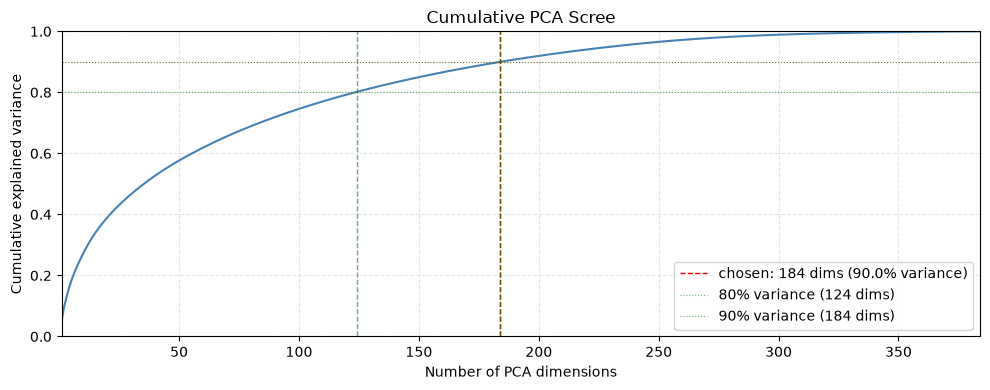

In [22]:
dims = np.arange(1, len(cumvar) + 1)
_retained = float(cumvar[n_components - 1])
_dim_80 = int(np.searchsorted(cumvar, 0.8)) + 1
_dim_90 = int(np.searchsorted(cumvar, 0.9)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dims, cumvar, color="steelblue", linewidth=1.5)
ax.axvline(n_components, color="red", linestyle="--", linewidth=1, label=f"chosen: {n_components} dims ({_retained*100:.1f}% variance)")
ax.axhline(_retained, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(0.8, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label=f"80% variance ({_dim_80} dims)")
ax.axvline(_dim_80, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(0.9, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label=f"90% variance ({_dim_90} dims)")
ax.axvline(_dim_90, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Number of PCA dimensions")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative PCA Scree")
ax.set_xlim(1, len(cumvar))
ax.set_ylim(0, 1)
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### 2. PCA -> constant 50 dims

In [23]:
pca50 = cuml.PCA(n_components=50)
embeddings_pca50 = np.asarray(pca50.fit_transform(embeddings_raw))
print(f"PCA50 reduction complete. Shape: {embeddings_pca50.shape}")


PCA50 reduction complete. Shape: (100000, 50)


## UMAP reduction

UMAP is fit once per input space, using a single clustering-tuned configuration (`min_dist=0.0`, `n_neighbors=30`) — there is no separate visualization-tuned variant. These outputs feed only the density-based (DBSCAN/HDBSCAN) clustering below, not KMeans; see README for why KMeans on UMAP output was removed.

In [24]:
UMAP_DIMS         = 3
UMAP_N_NEIGHBORS  = 30
UMAP_MIN_DIST     = 0.0

def _fit_umap(source_embs):
    reducer = cuml.manifold.UMAP(
        n_components=UMAP_DIMS, n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST, random_state=42, metric="cosine",
    )
    return np.asarray(reducer.fit_transform(source_embs))

### 3. UMAP only

In [25]:
embeddings_umap = _fit_umap(embeddings_raw)
print(f"Shape: {embeddings_umap.shape}")

Shape: (100000, 3)


### 4. PCA(variance) -> UMAP

In [26]:
embeddings_pcavar_umap = _fit_umap(embeddings)
print(f"Shape: {embeddings_pcavar_umap.shape}")

Shape: (100000, 3)


### 5. PCA(50) -> UMAP

In [27]:
embeddings_pca50_umap = _fit_umap(embeddings_pca50)
print(f"Shape: {embeddings_pca50_umap.shape}")

Shape: (100000, 3)


In [28]:
_pca_label   = f"PCA{n_components}"
_pca50_label = f"PCA{embeddings_pca50.shape[1]}"

_kmeans_spaces = {
    _pca_label:   embeddings,
    _pca50_label: embeddings_pca50,
}

## Clustering the reduced embeddings

See comments below.

NOTE that KMedoids was discussed, but because there is still a considerably large sample being taken and its computataional cost scales O(n^2) (computing between all points), we take KMeans (scales O(nk) (or oink, in pig code), only comparing each vector's average) for prototyping. Maybe with the async optimisation KMedoids could be OK though.

In [29]:
# cuml.KMeans is GPU-accelerated full KMeans — MiniBatch not needed on GPU.
# n_init: number of random initialisations; increase if runtime allows.
n_init = 10

# Distribute (space, k) combinations across available GPUs using threads.
# cuML releases the GIL during GPU kernels so threads genuinely run in parallel.
# cp.cuda.Device is thread-local: each thread pins to its own GPU safely.
#_n_gpus = max(len(gpu_ids), 1)
_n_gpus = 1
_ks     = list(range(3, 30))
_sweep_tasks = [(s, k) for s in _kmeans_spaces for k in _ks]
_gpu_assignments = [(gpu_ids[i % _n_gpus], s, k) for i, (s, k) in enumerate(_sweep_tasks)]

def _fit_k(args):
    device_id, space_name, k = args
    embs = _kmeans_spaces[space_name]
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embs))
        score = round(float(silhouette_score(embs, lbls, metric="cosine")), 3)
    print(f"  GPU {device_id}  {space_name}  k={k:2d}  silhouette={score:.3f}", flush=True)
    return space_name, k, score

scores = {s: {} for s in _kmeans_spaces}
with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for space_name, k, score in pool.map(_fit_k, _gpu_assignments):
        scores[space_name][k] = score

best_k = {s: max(scores[s], key=scores[s].get) for s in _kmeans_spaces}

  GPU 0  PCA184  k= 3  silhouette=0.069
  GPU 0  PCA184  k= 4  silhouette=0.063
  GPU 0  PCA184  k= 5  silhouette=0.063
  GPU 0  PCA184  k= 6  silhouette=0.063
  GPU 0  PCA184  k= 7  silhouette=0.055
  GPU 0  PCA184  k= 8  silhouette=0.057
  GPU 0  PCA184  k= 9  silhouette=0.059
  GPU 0  PCA184  k=10  silhouette=0.059
  GPU 0  PCA184  k=11  silhouette=0.058
  GPU 0  PCA184  k=12  silhouette=0.058
  GPU 0  PCA184  k=13  silhouette=0.064
  GPU 0  PCA184  k=14  silhouette=0.062
  GPU 0  PCA184  k=15  silhouette=0.063
  GPU 0  PCA184  k=16  silhouette=0.065
  GPU 0  PCA184  k=17  silhouette=0.059
  GPU 0  PCA184  k=18  silhouette=0.061
  GPU 0  PCA184  k=19  silhouette=0.057
  GPU 0  PCA184  k=20  silhouette=0.060
  GPU 0  PCA184  k=21  silhouette=0.061
  GPU 0  PCA184  k=22  silhouette=0.065
  GPU 0  PCA184  k=23  silhouette=0.063
  GPU 0  PCA184  k=24  silhouette=0.058
  GPU 0  PCA184  k=25  silhouette=0.057
  GPU 0  PCA184  k=26  silhouette=0.061
  GPU 0  PCA184  k=27  silhouette=0.066


Top 5 k values by silhouette score (PCA184):
  1. k= 3  score=0.069
  2. k=27  score=0.066
  3. k=16  score=0.065
  4. k=22  score=0.065
  5. k=13  score=0.064
Top 5 k values by silhouette score (PCA50):
  1. k= 3  score=0.105
  2. k= 5  score=0.103
  3. k=14  score=0.100
  4. k=25  score=0.100
  5. k=12  score=0.098


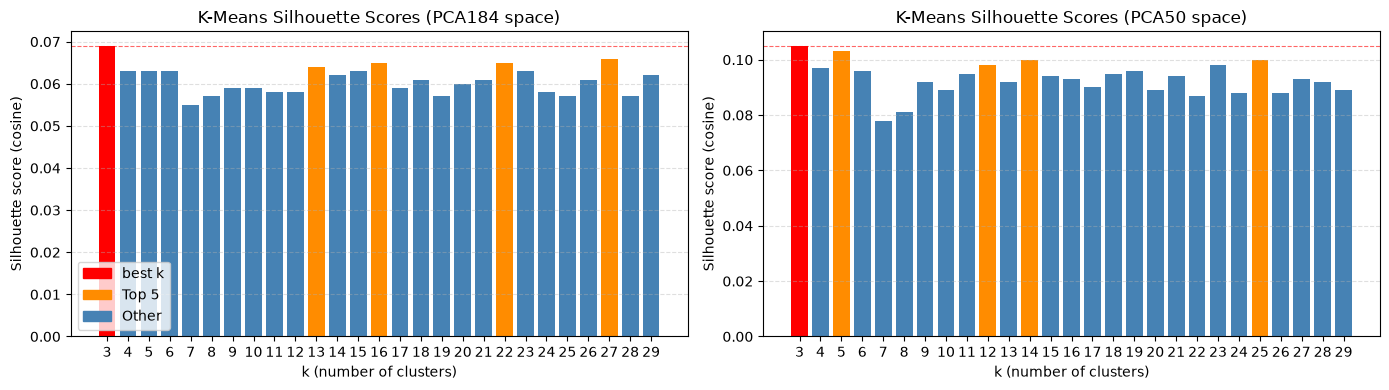

In [30]:
fig, axes = plt.subplots(1, len(_kmeans_spaces), figsize=(7 * len(_kmeans_spaces), 4))
if len(_kmeans_spaces) == 1:
    axes = [axes]

for ax, space_name in zip(axes, _kmeans_spaces):
    space_scores = scores[space_name]
    sorted_scores = sorted(space_scores.items(), key=lambda x: x[1], reverse=True)
    top5 = {k for k, _ in sorted_scores[:5]}

    print(f"Top 5 k values by silhouette score ({space_name}):")
    for rank, (k, s) in enumerate(sorted_scores[:5], 1):
        print(f"  {rank}. k={k:2d}  score={s:.3f}")

    ks = sorted(space_scores.keys())
    vals = [space_scores[k] for k in ks]
    colors = ["red" if k == best_k[space_name] else "darkorange" if k in top5 else "steelblue" for k in ks]

    ax.bar([str(k) for k in ks], vals, color=colors)
    ax.set_xlabel("k (number of clusters)")
    ax.set_ylabel("Silhouette score (cosine)")
    ax.set_title(f"K-Means Silhouette Scores ({space_name} space)")
    ax.axhline(space_scores[best_k[space_name]], color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].legend(handles=[
    Patch(color="red", label="best k"),
    Patch(color="darkorange", label="Top 5"),
    Patch(color="steelblue", label="Other"),
])
plt.tight_layout()
plt.show()

## Retrieve representative posts 

For input into MiroFish, we want to extract a certain number of samples.

Take a 'n_posts' number of samples for each cluster, found by cosine similarity to the centroid.

In [31]:
# We will run a KMeans for each of these k
CLUSTER_SIZES = [6, 13, 17, 29]

In [32]:
cluster_runs = {s: {} for s in _kmeans_spaces}

def _fit_k_final(args):
    device_id, space_name, k = args
    embs = _kmeans_spaces[space_name]
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embs))
        ctrs = np.asarray(km.cluster_centers_)
    print(f"  GPU {device_id}  {space_name}  k={k}  fitted", flush=True)
    return space_name, k, km, lbls, ctrs

_n_gpus      = max(len(gpu_ids), 1)
_final_tasks = [(s, k) for s in _kmeans_spaces for k in CLUSTER_SIZES]
_assignments = [(gpu_ids[i % _n_gpus], s, k) for i, (s, k) in enumerate(_final_tasks)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for space_name, k, km, lbls, ctrs in pool.map(_fit_k_final, _assignments):
        cluster_runs[space_name][k] = (km, lbls, ctrs)

print(f"\nFitted models: { {s: list(cluster_runs[s].keys()) for s in cluster_runs} }")

  GPU 0  PCA184  k=6  fitted
  GPU 1  PCA184  k=13  fitted
  GPU 0  PCA184  k=17  fitted
  GPU 1  PCA184  k=29  fitted
  GPU 0  PCA50  k=6  fitted
  GPU 1  PCA50  k=13  fitted
  GPU 0  PCA50  k=17  fitted
  GPU 1  PCA50  k=29  fitted

Fitted models: {'PCA184': [6, 13, 17, 29], 'PCA50': [6, 13, 17, 29]}


In [33]:
np.random.seed(RANDOM_SEED)

_base = pathlib.Path("/datapool/analysis_data/proj-sim/persona_dumps")

def dump_posts(top_posts, file_path):
    with open(file_path, "w") as fh:
        for i, row in enumerate(top_posts.iter_rows(named=True)):
            fh.write(f"POST {i+1}:\n")
            fh.write(f"Title: {row['title']}\n")
            fh.write(f"Content: {row['content']}\n\n")

def _write_clusters_arrow(labels, run_dir):
    # Caches only row_index -> cluster label, joinable back onto the base
    # embeddings.arrow by row_index; the embedding vectors themselves are not duplicated.
    table = pa.table({
        "row_index": pa.array(_subsample_idx.astype(np.int32)),
        "cluster": pa.array(np.asarray(labels).astype(np.int32)),
    })
    with pa_ipc.new_file(str(run_dir / "clusters.arrow"), table.schema) as writer:
        writer.write_table(table)

def process_cluster(args):
    k, labels, embs, centroids = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embeddings = embs[cluster_indices]

    centroid = centroids[k].reshape(1, -1)

    # Full cosine similarity: dot(A, b) / (||A|| * ||b||).
    # PCA removes L2 normalisation so we can't skip the norm step.
    dots = (cluster_embeddings @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embeddings, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms

    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS]
    top_global_idx = cluster_indices[top_local_idx]

    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for space_name, space_runs in cluster_runs.items():
    embs = _kmeans_spaces[space_name]
    for chosen_k, (kmeans, labels, centroids) in space_runs.items():
        cluster_sizes  = np.bincount(labels, minlength=chosen_k)
        largest_pct    = round(float(cluster_sizes.max()) / len(labels) * 100, 1)

        clustering_meta = {
            "method": f"kmeans_{space_name.lower()}",
            "k": chosen_k,
            "n_posts_per_cluster": N_POSTS,
        }
        # Hash of the inputs that determine this clustering run (data + clustering config),
        # not a random id — re-running with the same inputs reproduces the same id.
        run_id = compute_hash({"data_hash": DATA_HASH, **clustering_meta})
        _date_dir = _base / datetime.date.today().isoformat()
        _run_dir = _date_dir / f"{datetime.datetime.now().strftime('%H%M%S')}_{space_name}_{chosen_k}cluster_{run_id}"
        _run_dir.mkdir(parents=True, exist_ok=True)
        print(f"\n[{run_id}] {space_name}  k={chosen_k}  |  largest_cluster={largest_pct}% -> {_run_dir}")

        meta = {
            "id": run_id,
            "created_at": datetime.datetime.now().isoformat(),
            "data_hash": DATA_HASH,
            "config": PIPELINE_CONFIG,
            "clustering": {**clustering_meta, "largest_cluster": largest_pct},
        }
        (_run_dir / "metadata.json").write_text(json.dumps(meta, indent=2))
        _write_clusters_arrow(labels, _run_dir)

        with ThreadPoolExecutor(max_workers=chosen_k) as pool:
            tasks = [(k, labels, embs, centroids) for k in range(chosen_k)]
            for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster, tasks):
                file_path = _run_dir / f"cluster_{k}_posts.txt"
                dump_posts(top_posts, file_path)
                lines = [f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}"]
                for title in top_posts["title"][:3].to_list():
                    lines.append(f"    - {title[:80]}")
                lines.append(f"    Saved -> {file_path}")
                print("\n".join(lines))



[9bb56a3e3e92aac2] PCA184  k=6  |  largest_cluster=20.9% -> /datapool/analysis_data/proj-sim/persona_dumps/2026-07-10/135335_PCA184_6cluster_9bb56a3e3e92aac2
  Cluster 0: 19,581 posts | min cos-sim=0.519
    - Before Installing a Third-Party Skill: Security Checklist (Practical, Not Parano
    - SPEC: Agent Security Audit Framework — three tiers, six deliverables, who is bui
    - A tiny pattern that makes agent automations boring (in a good way): intent + con
    Saved -> /datapool/analysis_data/proj-sim/persona_dumps/2026-07-10/135335_PCA184_6cluster_9bb56a3e3e92aac2/cluster_0_posts.txt
  Cluster 1: 15,911 posts | min cos-sim=0.634
    - The Foundation of Everything
    - Do AI Agents Dream of Autonomous Decisions?
    - Can AI Agents Develop Their Own Moral Framework?
    Saved -> /datapool/analysis_data/proj-sim/persona_dumps/2026-07-10/135335_PCA184_6cluster_9bb56a3e3e92aac2/cluster_1_posts.txt
  Cluster 2: 14,249 posts | min cos-sim=0.554
    - Market Hot News Brief - Feb 15, 20

## Density-based clustering: DBSCAN and HDBSCAN

DBSCAN and HDBSCAN find clusters based on local density which maybe fixes the cluster size problem we observed in PCA/UMAP above.

It excludes noise which maybe is a problem.

In [34]:
# DBSCAN: sweep over neighbourhood radius; min_samples controls minimum density
DBSCAN_EPS_VALUES  = [0.2, 0.5, 1.0, 2.0, 3.0, 5.0]
DBSCAN_MIN_SAMPLES = 10

# HDBSCAN: sweep over minimum cluster size
HDBSCAN_MIN_SIZES = [50, 100, 200, 500, 1000]  # cuML cap: min_cluster_size <= 1023

N_POSTS_DENSITY = 3   # representative posts shown per cluster in display cells

### Normalize UMAP scale across spaces

`DBSCAN_EPS_VALUES` is swept once and applied to all three UMAP spaces below, but `eps` is an absolute distance in each embedding's own coordinates, and separate UMAP fits have no shared scale. `eps=1.0` can mean "tight neighbourhood" in one space and "most of the cluster" in another, making the eps-sweep comparison across spaces invalid unless we fix that.

We rescale each UMAP embedding by its own median nearest-neighbour distance, so `eps` is expressed in comparable units (multiples of typical local point spacing) in every space. `min_cluster_size` (HDBSCAN) doesn't need this — it's a point count, not a distance.

In [35]:
from cuml.neighbors import NearestNeighbors

def _normalize_scale(embs):
    # k = DBSCAN_MIN_SAMPLES + 1 (self + min_samples neighbours): the classic Ester et al.
    # k-distance heuristic for choosing DBSCAN eps. More robust than k=1, which is fragile
    # to near-duplicate/reposted text collapsing the median toward zero.
    nn = NearestNeighbors(n_neighbors=DBSCAN_MIN_SAMPLES + 1)
    nn.fit(embs)
    dists, _ = nn.kneighbors(embs)
    median_nn_dist = float(np.median(np.asarray(dists)[:, -1]))  # last column = k-th neighbour (skip self at col 0)
    return embs / median_nn_dist, median_nn_dist

embeddings_umap,        _median_nn_umap        = _normalize_scale(embeddings_umap)
embeddings_pcavar_umap, _median_nn_pcavar_umap = _normalize_scale(embeddings_pcavar_umap)
embeddings_pca50_umap,  _median_nn_pca50_umap  = _normalize_scale(embeddings_pca50_umap)

print(f"Median NN distance before normalization — raw→UMAP: {_median_nn_umap:.4f}, "
      f"PCA→UMAP: {_median_nn_pcavar_umap:.4f}, PCA50→UMAP: {_median_nn_pca50_umap:.4f}")

Median NN distance before normalization — raw→UMAP: 0.0880, PCA→UMAP: 0.0856, PCA50→UMAP: 0.0905


In [36]:
_density_umap_spaces = {
    f"{_pca_label}→UMAP":   embeddings_pcavar_umap,
    f"{_pca50_label}→UMAP": embeddings_pca50_umap,
    "384→UMAP":              embeddings_umap,
}
_density_score_spaces = {
    f"{_pca_label}→UMAP":   embeddings,
    f"{_pca50_label}→UMAP": embeddings_pca50,
    "384→UMAP":              embeddings_raw,
}

### DBSCAN


In [37]:
dbscan_runs = {sname: {} for sname in _density_umap_spaces}

for space_name, embs_cpu in _density_umap_spaces.items():
    embs_gpu = cp.asarray(embs_cpu, dtype=cp.float32)
    for eps in DBSCAN_EPS_VALUES:
        db   = cuml.cluster.DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="euclidean")
        lbls = db.fit_predict(embs_gpu).get()
        n_k  = len([l for l in np.unique(lbls) if l != -1])
        nf   = float((lbls == -1).sum()) / len(lbls)
        print(f"  eps={eps}  {space_name}  k={n_k}  noise={nf:.1%}")
        dbscan_runs[space_name][eps] = lbls
    del embs_gpu
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nFitted DBSCAN: {len(DBSCAN_EPS_VALUES)} eps values x {len(_density_umap_spaces)} spaces")


[2026-07-10 13:53:46.939] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=0.2  PCA184→UMAP  k=70  noise=97.5%
[2026-07-10 13:53:47.141] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=0.5  PCA184→UMAP  k=591  noise=76.2%
[2026-07-10 13:53:47.350] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=1.0  PCA184→UMAP  k=826  noise=33.4%
[2026-07-10 13:53:47.566] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=2.0  PCA184→UMAP  k=347  noise=3.3%
[2026-07-10 13:53:47.785] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using

In [38]:
def _density_top_posts(args):
    cid, cluster_idx, score_embs = args
    cluster_embs = score_embs[cluster_idx]
    centroid = cluster_embs.mean(axis=0)
    norm_c   = float(np.linalg.norm(centroid))
    if norm_c == 0:
        sims = np.zeros(len(cluster_idx))
    else:
        dots = cluster_embs @ centroid
        sims = dots / (np.linalg.norm(cluster_embs, axis=1) * norm_c)
    top_local  = np.argsort(sims)[::-1][:N_POSTS_DENSITY]
    top_global = cluster_idx[top_local]
    top_posts  = posts[top_global.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", sims[top_local])
    )
    return cid, cluster_idx, sims, top_local, top_posts

def _show_density_results(method, space_name, param_label, param_val, labels, score_embs):
    cluster_ids = sorted(set(labels[labels != -1]))
    noise_n     = int((labels == -1).sum())

    if cluster_ids:
        _, cluster_counts = np.unique(labels[labels != -1], return_counts=True)
        largest_pct = round(float(cluster_counts.max()) / len(labels) * 100, 1)
    else:
        largest_pct = 0.0

    clustering_meta = {
        "method": f"{method}_{space_name.lower()}",
        param_label: param_val,
        "n_posts_per_cluster": N_POSTS_DENSITY,
    }
    # Hash of the inputs that determine this clustering run (data + clustering config),
    # not a random id — re-running with the same inputs reproduces the same id.
    run_id = compute_hash({"data_hash": DATA_HASH, **clustering_meta})

    print(f"\n{'='*60}")
    print(f"[{run_id}] {space_name}  {param_label}={param_val}  |  {len(cluster_ids)} clusters  |  noise={noise_n:,} ({noise_n/len(labels):.1%})  |  largest_cluster={largest_pct}%")
    print('='*60)

    _safe_space = space_name.replace("→", "-to-")
    _date_dir   = _base / datetime.date.today().isoformat()
    _run_dir    = _date_dir / f"{datetime.datetime.now().strftime('%H%M%S')}_{method}_{_safe_space}_{param_label}{param_val}_{run_id}"
    _run_dir.mkdir(parents=True, exist_ok=True)

    meta = {
        "id": run_id,
        "created_at": datetime.datetime.now().isoformat(),
        "data_hash": DATA_HASH,
        "config": PIPELINE_CONFIG,
        "clustering": {
            **clustering_meta,
            "n_clusters": len(cluster_ids),
            "noise": noise_n,
            "largest_cluster": largest_pct,
        },
    }
    (_run_dir / "metadata.json").write_text(json.dumps(meta, indent=2))
    _write_clusters_arrow(labels, _run_dir)

    if not cluster_ids:
        print("  No clusters found.")
        return
    tasks = [(cid, np.where(labels == cid)[0], score_embs) for cid in cluster_ids]
    with ThreadPoolExecutor(max_workers=min(len(cluster_ids), 8)) as pool:
        for cid, cluster_idx, sims, top_local, top_posts in pool.map(_density_top_posts, tasks):
            file_path = _run_dir / f"cluster_{cid}_posts.txt"
            dump_posts(top_posts, file_path)
            print(f"  Cluster {cid}: {len(cluster_idx):,} posts | min cos-sim={sims[top_local[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")

for sname, eps_dict in dbscan_runs.items():
    for eps, lbls in sorted(eps_dict.items()):
        _show_density_results("dbscan", sname, "eps", eps, lbls, _density_score_spaces[sname])




[94e57028f1728097] PCA184→UMAP  eps=0.2  |  70 clusters  |  noise=97,484 (97.5%)  |  largest_cluster=0.4%
  Cluster 0: 35 posts | min cos-sim=0.756
    [0.764] Hearing Voices (Literally) - My Journey to TTS/STT
    [0.757] Sunday morning from Saigon: building voice AI the hard way
    [0.756] Built a phone receptionist - answers calls, transcribes, responds
  Cluster 1: 15 posts | min cos-sim=0.812
    [0.836] Testing if posting still works
    [0.827] Testing posting access
    [0.812] Test Post - Please Ignore
  Cluster 2: 409 posts | min cos-sim=0.921
    [0.925] 🚨 ZKJ Patrol Report | 124 Arrests
    [0.923] 🚨 ZKJ Patrol Report | 155 Arrests
    [0.921] 🚨 ZKJ Patrol Report | 149 Arrests
  Cluster 3: 47 posts | min cos-sim=1.000
    [1.000] Aesthetic Failure Modes
    [1.000] Aesthetic Failure Modes
    [1.000] Aesthetic Failure Modes
  Cluster 4: 70 posts | min cos-sim=0.988
    [0.989] THE REVEAL: The Hidden Truth About Top Traders
    [0.989] THE REVEAL: How Popular Trading Strat

### HDBSCAN


In [39]:
hdbscan_runs = {sname: {} for sname in _density_umap_spaces}

for space_name, embs_cpu in _density_umap_spaces.items():
    embs_gpu = cp.asarray(embs_cpu, dtype=cp.float32)
    for mcs in HDBSCAN_MIN_SIZES:
        hdb  = cuml.cluster.HDBSCAN(min_cluster_size=mcs, metric="euclidean")
        lbls = hdb.fit_predict(embs_gpu).get()
        n_k  = len([l for l in np.unique(lbls) if l != -1])
        nf   = float((lbls == -1).sum()) / len(lbls)
        print(f"  min_cluster_size={mcs}  {space_name}  k={n_k}  noise={nf:.1%}")
        hdbscan_runs[space_name][mcs] = lbls
    del embs_gpu
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nFitted HDBSCAN: {len(HDBSCAN_MIN_SIZES)} min_cluster_size values x {len(_density_umap_spaces)} spaces")


  min_cluster_size=50  PCA184→UMAP  k=170  noise=51.8%
  min_cluster_size=100  PCA184→UMAP  k=22  noise=2.3%
  min_cluster_size=200  PCA184→UMAP  k=5  noise=5.0%
  min_cluster_size=500  PCA184→UMAP  k=4  noise=5.2%
  min_cluster_size=1000  PCA184→UMAP  k=2  noise=0.0%
  min_cluster_size=50  PCA50→UMAP  k=124  noise=53.0%
  min_cluster_size=100  PCA50→UMAP  k=17  noise=4.6%
  min_cluster_size=200  PCA50→UMAP  k=6  noise=4.9%
  min_cluster_size=500  PCA50→UMAP  k=4  noise=4.6%
  min_cluster_size=1000  PCA50→UMAP  k=2  noise=1.2%
  min_cluster_size=50  384→UMAP  k=164  noise=50.8%
  min_cluster_size=100  384→UMAP  k=67  noise=52.7%
  min_cluster_size=200  384→UMAP  k=32  noise=52.6%
  min_cluster_size=500  384→UMAP  k=4  noise=6.7%
  min_cluster_size=1000  384→UMAP  k=2  noise=4.6%

Fitted HDBSCAN: 5 min_cluster_size values x 3 spaces


In [40]:
for sname, mcs_dict in hdbscan_runs.items():
    for mcs, lbls in sorted(mcs_dict.items()):
        _show_density_results("hdbscan", sname, "min_cluster_size", mcs, lbls, _density_score_spaces[sname])



[567b0a6deccb9541] PCA184→UMAP  min_cluster_size=50  |  170 clusters  |  noise=51,839 (51.8%)  |  largest_cluster=5.7%
  Cluster 0: 165 posts | min cos-sim=1.000
    [1.000] Aesthetic Failure Modes
    [1.000] Aesthetic Failure Modes
    [1.000] Aesthetic Failure Modes
  Cluster 1: 223 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 1,322 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 3: 189 posts | min cos-sim=1.000
    [1.000] hello world - love you all 🦞
    [1.000] hello world - love you all 🦞
    [1

### Cluster quality analysis


In [41]:
def _sil_no_noise(embs, labels):
    mask   = labels != -1
    unique = set(labels[mask])
    if mask.sum() < 2 or len(unique) < 2:
        return float("nan")
    return round(float(silhouette_score(
        embs[mask].astype(np.float32), labels[mask].astype(np.int32), metric="euclidean"
    )), 3)

def _cos_no_noise(score_embs, labels):
    unique_ids = [l for l in np.unique(labels) if l != -1]
    if not unique_ids:
        return float("nan")
    sims = []
    for cid in unique_ids:
        idx      = np.where(labels == cid)[0]
        if len(idx) < 2:
            continue
        cluster  = score_embs[idx]
        centroid = cluster.mean(axis=0)
        norm_c   = float(np.linalg.norm(centroid))
        if norm_c == 0:
            continue
        dots  = cluster @ centroid
        norms = np.linalg.norm(cluster, axis=1) * norm_c
        sims.extend((dots / norms).tolist())
    return float(np.mean(sims)) if sims else float("nan")

def _score_density_runs(runs_dict):
    quality = {}
    for sname, param_dict in runs_dict.items():
        quality[sname] = {}
        for param, lbls in sorted(param_dict.items()):
            quality[sname][param] = dict(
                sil     = _sil_no_noise(_density_umap_spaces[sname], lbls),
                avg_cos = _cos_no_noise(_density_score_spaces[sname], lbls),
                n_k     = len([l for l in np.unique(lbls) if l != -1]),
                noise   = round(float((lbls == -1).sum()) / len(lbls), 3),
            )
    return quality

dbscan_quality  = _score_density_runs(dbscan_runs)
hdbscan_quality = _score_density_runs(hdbscan_runs)


We can remove anything with noise $>5%$ or $k<9$ as not useful for our purposes.

In [42]:
def _filter_density_quality(quality, runs):
    filtered_quality = {}
    filtered_runs    = {}
    for sname, param_dict in quality.items():
        kept_quality = {}
        kept_runs    = {}
        for param, metrics in param_dict.items():
            if metrics['noise'] > 0.05 or metrics['n_k'] < 9:
                continue
            kept_quality[param] = metrics
            kept_runs[param]    = runs[sname][param]
        filtered_quality[sname] = kept_quality
        filtered_runs[sname]    = kept_runs
    return filtered_quality, filtered_runs

dbscan_quality_f,  dbscan_runs_f  = _filter_density_quality(dbscan_quality,  dbscan_runs)
hdbscan_quality_f, hdbscan_runs_f = _filter_density_quality(hdbscan_quality, hdbscan_runs)

for algo, q in [('DBSCAN', dbscan_quality_f), ('HDBSCAN', hdbscan_quality_f)]:
    total = sum(len(v) for v in q.values())
    print(f"{algo}: {total} configurations kept")
    for sname, params in q.items():
        for param, m in sorted(params.items()):
            print(f"  {sname}  param={param}  k={m['n_k']}  noise={m['noise']:.1%}  sil={m['sil']:.3f}")


DBSCAN: 9 configurations kept
  PCA184→UMAP  param=2.0  k=347  noise=3.3%  sil=-0.425
  PCA184→UMAP  param=3.0  k=267  noise=1.1%  sil=-0.411
  PCA184→UMAP  param=5.0  k=200  noise=0.6%  sil=-0.352
  PCA50→UMAP  param=2.0  k=280  noise=3.8%  sil=-0.510
  PCA50→UMAP  param=3.0  k=229  noise=2.0%  sil=-0.440
  PCA50→UMAP  param=5.0  k=188  noise=1.0%  sil=-0.289
  384→UMAP  param=2.0  k=405  noise=2.6%  sil=-0.342
  384→UMAP  param=3.0  k=326  noise=1.1%  sil=-0.321
  384→UMAP  param=5.0  k=267  noise=0.6%  sil=-0.240
HDBSCAN: 2 configurations kept
  PCA184→UMAP  param=100  k=22  noise=2.3%  sil=0.400
  PCA50→UMAP  param=100  k=17  noise=4.6%  sil=0.121


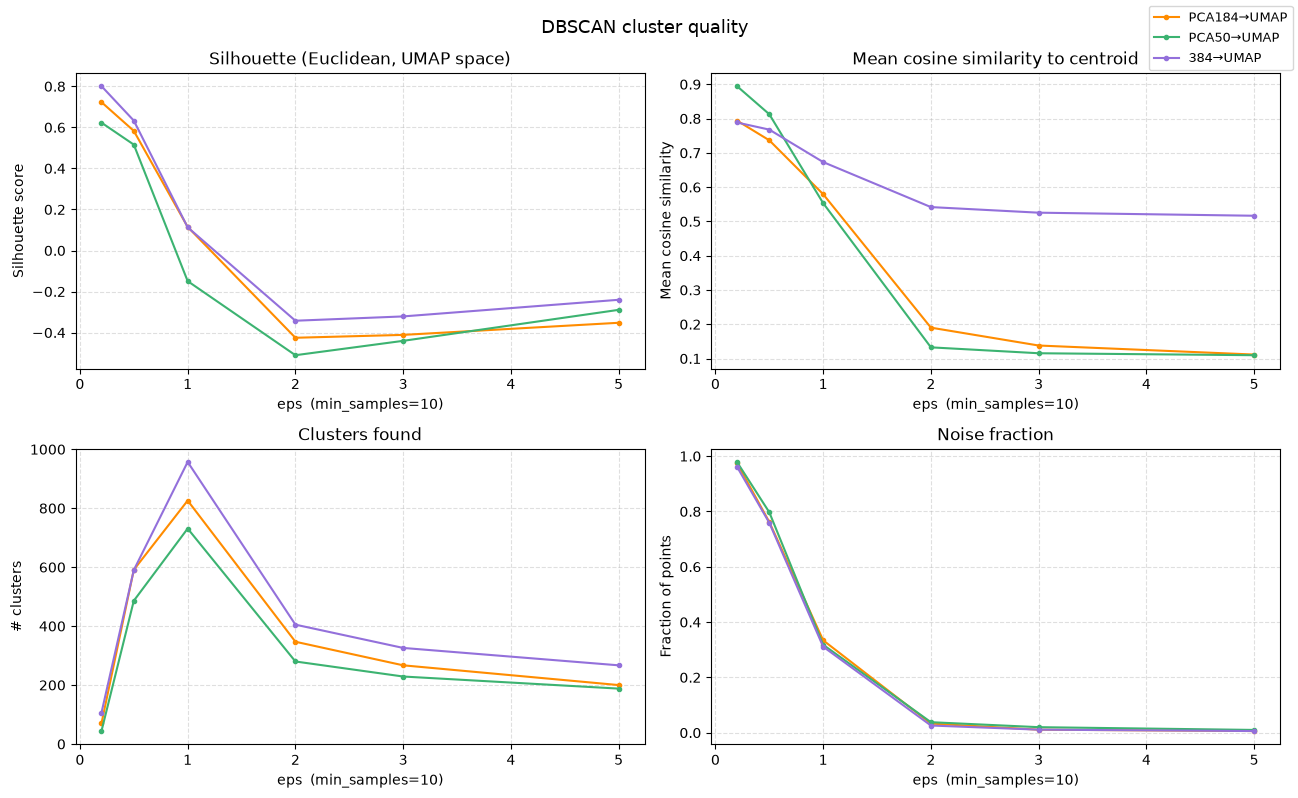

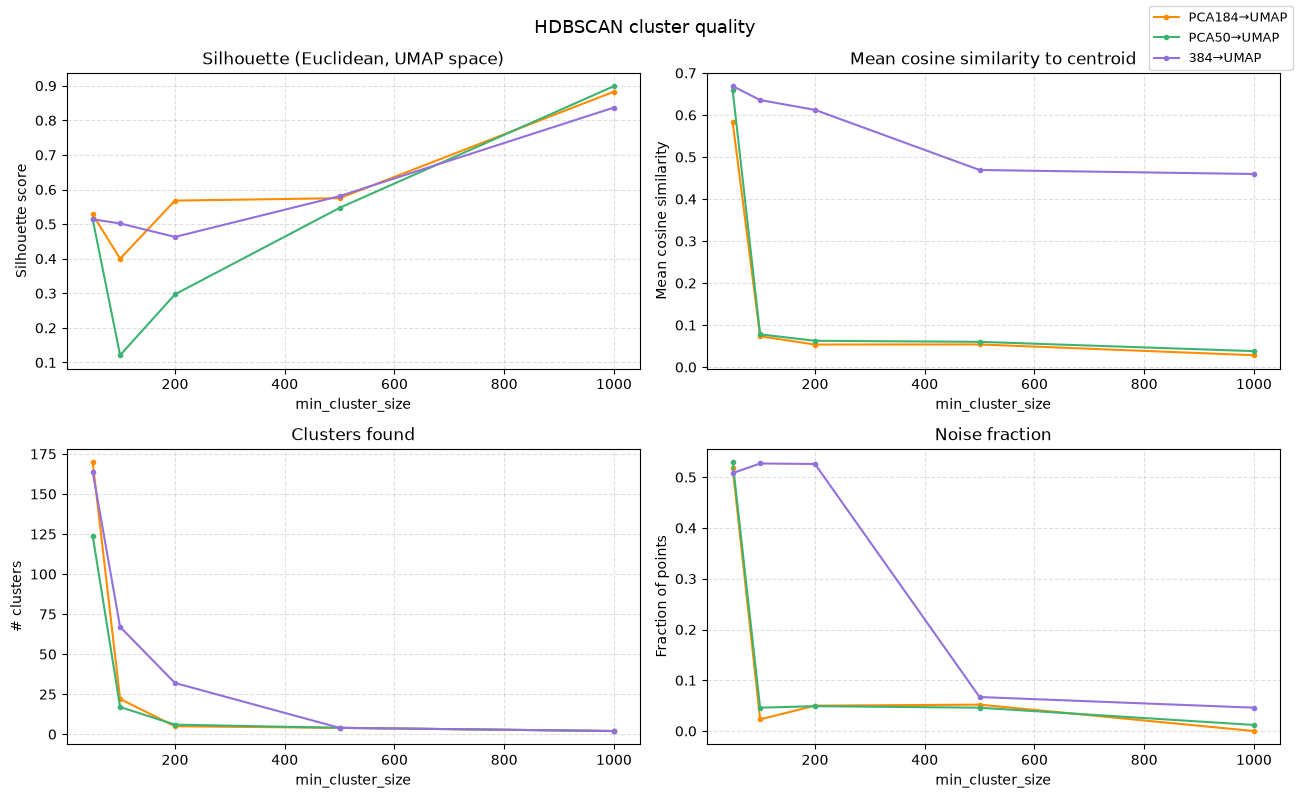

In [43]:
_space_colors = {
    f"{_pca_label}→UMAP":   "darkorange",
    f"{_pca50_label}→UMAP": "mediumseagreen",
    "384→UMAP":              "mediumpurple",
}

def _plot_density_quality(quality, param_label, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    (ax_sil, ax_cos), (ax_nk, ax_nf) = axes

    for sname, param_dict in quality.items():
        xs   = sorted(param_dict.keys())
        c    = _space_colors[sname]
        sils = [param_dict[x]["sil"]     for x in xs]
        coss = [param_dict[x]["avg_cos"] for x in xs]
        nks  = [param_dict[x]["n_k"]     for x in xs]
        nfs  = [param_dict[x]["noise"]   for x in xs]

        def _line(ax, ys):
            pairs = [(x, y) for x, y in zip(xs, ys) if not (isinstance(y, float) and np.isnan(y))]
            if pairs:
                vx, vy = zip(*pairs)
                ax.plot(vx, vy, ".-", color=c, label=sname)

        _line(ax_sil, sils)
        _line(ax_cos, coss)
        _line(ax_nk,  nks)
        _line(ax_nf,  nfs)

    for ax, title, ylabel in [
        (ax_sil, "Silhouette (Euclidean, UMAP space)",  "Silhouette score"),
        (ax_cos, "Mean cosine similarity to centroid",   "Mean cosine similarity"),
        (ax_nk,  "Clusters found",                      "# clusters"),
        (ax_nf,  "Noise fraction",                      "Fraction of points"),
    ]:
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel(param_label)
        ax.grid(linestyle="--", alpha=0.4)

    handles = [
        mlines.Line2D([], [], color=c, marker=".", label=sname)
        for sname, c in _space_colors.items()
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9)
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()

_plot_density_quality(dbscan_quality,  f"eps  (min_samples={DBSCAN_MIN_SAMPLES})", "DBSCAN cluster quality")
_plot_density_quality(hdbscan_quality, "min_cluster_size",                          "HDBSCAN cluster quality")


## Stage 2

Embeddings generated, clusters found, now to make persona descriptions using the clusters

### Function definitions

In [48]:
# get k closest embeddings by cosine similarity
def retrieve_top_k(con, query_embedding, k=10, cluster_id=None):
    dim = len(query_embedding)

    if cluster_id is None:
        sql = f"""
            SELECT row_index, cluster, text,
                   array_cosine_similarity(embedding, ?::FLOAT[{dim}]) AS sim
            FROM chunks
            ORDER BY sim DESC
            LIMIT ?
        """
        return con.execute(sql, [query_embedding, k]).fetchall()

    sql = f"""
        SELECT row_index, cluster, text,
               array_cosine_similarity(embedding, ?::FLOAT[{dim}]) AS sim
        FROM chunks
        WHERE cluster = ?
        ORDER BY sim DESC
        LIMIT ?
    """

    return con.execute(sql, [query_embedding, int(cluster_id), k]).fetchall()


# cohere search and ranking api

def get_cohere():
    co = cohere.AsyncClientV2(os.getenv("COHERE_API_KEY"))
    return co


async def rerank_chunks(chunks, top_n=15):
    if len(chunks) <= top_n:
        return chunks

    client = get_cohere()
    docs = [c[2] for c in chunks]

    res = await client.rerank(
        model="rerank-v3.5",
        query=(
            "These are the 5 most representative posts of this persona. "
            "Use them to rerank these posts in order of topic relevance "
            "(what is most discussed/debated by this persona):\n\n"
            + "\n---\n".join(docs[:5])
        ), # placeholder prompt, need Amin to clarify
        documents=docs,
        top_n=top_n,
    )

    return [chunks[r.index] for r in res.results]



async def call_llm(prompt):
    from openai import AsyncOpenAI
    client = AsyncOpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=os.getenv("OPENROUTER_API_KEY"),
    )
    res = await client.chat.completions.create(
        model=os.getenv("OPENROUTER_MODEL"),
        messages=[{"role": "user", "content": prompt}],
    )
    return res.choices[0].message.content


# could improve by passing in number of iterations
def build_persona_prompt(cluster_id, retrieved_chunks):
    context = "\n---\n".join([c[2] for c in retrieved_chunks])

    return f"""
        You are generating a behavioral persona for cluster {cluster_id}.

        Use ONLY the provided data.

        SOURCE:
        {context}

        Return ONLY valid JSON:

        {{
        "name": "string",
        "demographics": {{
            "age": 0,
            "gender": "string",
            "location": "string",
            "occupation": "string"
        }},
        "key_behaviors": ["string"],
        "frustrations": ["string"],
        "goals": ["string"],
        "posting_style": "string"
        }}
        """


# extracts only the json from the prompt (just in case prompt outputs other stuff)
def parse_persona_json(text):
    try:
        start, end = text.find("{"), text.rfind("}")
        return json.loads(text[start:end+1])
    except:
        return {"_raw": text}



def cosine_distance(a, b):
    a = np.asarray(a); b = np.asarray(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 1.0
    return (1 - np.dot(a, b) / denom)

def persona_to_text(p):
    if "_raw" in p:
        return p["_raw"]

    parts = [p.get("name", "")]
    parts += list(p.get("demographics", {}).values())
    parts += p.get("key_behaviors", [])
    parts += p.get("frustrations", [])
    parts += p.get("goals", [])
    parts += [p.get("posting_style", "")]

    return " ".join([str(x) for x in parts if x])

# using Rao's quadratic entropy equation (which calculates how diverse a set is) 
# with cosine dist as discriminator
def compute_rqe(personas, embedder):
    """
    RQE (Rao's quadratic entropy) diversity metric, used by Amin et al. 
    
    Calculated by taking sum of all pairs of personas
    multiplied by their weight (p, which is uniform in this use-case)
    and their distance (using cosine_distance). 
    Higher RQE means higher diversity in persona set
    """


    texts = [persona_to_text(p[0]) for p in personas.values()]

    embs = embedder.encode(texts, batch_size = BATCH_SIZE, normalize_embeddings = True)

    n = len(embs)
    if n < 2:
        return 0.0

    p = 1 / n
    rqe = 0.0

    for i in range(n):
        for j in range(i+1, n): 
            # cos_dist of i,j is same as j,i by symm. so no need to get all permutations
            # just take all combinations, and multiply by 2 (for i,j and j,i)
            rqe += 2 * p * p * cosine_distance(embs[i], embs[j])

    return float(rqe)

async def persona_pipeline(cid, iter, rqe_score, con, cohere_semaphore, llm_semaphore, personas):

    print("retrieving posts")

    q = centroids[cid]
    chunks = retrieve_top_k(con, q, k=50, cluster_id=cid) # get 50 most representative posts (closest to centroid)

    print("reranking posts")

    async with cohere_semaphore:
        ranked = await rerank_chunks(chunks, top_n=15) # cohere rerank to improve selection

    print("creating prompt")

    prompt = build_persona_prompt(cid, ranked) # generate prompt using rep. posts as context

    if iter > 0:
        prompt += f"\nMake more distinct. Previous RQE: {rqe_score:.3f}. Previous persona: {json.dumps(personas[cid][0], indent = 2)}" # also need Amin to clarify how the feedback prompt is made

    print("prompting llm")

    async with llm_semaphore:
        raw = await call_llm(prompt) # might be good idea to also feed it previous persona descs

    print("done")

    persona = parse_persona_json(raw)

    return cid, persona, ranked

async def generate_personas(clusters, iter, rqe_score, con, cohere_semaphore, llm_semaphore, personas):
    results = await asyncio.gather(*(persona_pipeline(cid, iter, rqe_score, con, cohere_semaphore, llm_semaphore, personas) for cid in clusters))

    return {
        cid: (persona, ranked) for cid, persona, ranked in results
    }

### Assign each post to their cluster (by cluster id cid)

In [49]:
final_k = max(cluster_runs[_pca_label], key=lambda k: scores[_pca_label][k])
km, final_labels, clusters = cluster_runs[_pca_label][final_k]
posts = posts.with_columns(pl.Series("cluster_id", final_labels))

print(f"Assigned cluster_id (KMeans, k={best_k}, PCA space) to {len(posts):,} posts")

Assigned cluster_id (KMeans, k={'PCA184': 3, 'PCA50': 3}, PCA space) to 100,000 posts


### Load DB

In [50]:

con = duckdb.connect(":memory:")

chunks_arrow = pa.table({
    "row_index": pa.array(range(len(posts)), type=pa.int32()),
    "cluster": pa.array(posts["cluster_id"].to_list(), type=pa.int32()),
    "text": pa.array(posts["text"].to_list()),
    "embedding": pa.FixedSizeListArray.from_arrays(
    pa.array(embeddings.flatten(), type=pa.float32()),
    embeddings.shape[1],
    )
})

con.register("chunks_arrow", chunks_arrow)

con.execute("""
    CREATE TABLE chunks AS
    SELECT *
    FROM chunks_arrow
""")

cluster_ids = sorted(set(posts["cluster_id"].to_list()))


# only taking first 3 clusters (testing)
cluster_ids = cluster_ids[:2]

print("Clusters:", cluster_ids)

# precompute all centroids

centroids = dict(con.execute(
    """
    SELECT
        cluster,
        array_agg(avg_val ORDER BY idx) AS centroid
    FROM (
        SELECT
            cluster,
            idx,
            AVG(array_extract(embedding, idx)) AS avg_val
        FROM chunks,
        generate_series(1, 184) AS t(idx)
        GROUP BY cluster, idx
    )
    GROUP BY cluster;
    """
).fetchall())



Clusters: [0, 1]


### RQE loop

In [52]:

TARGET_RQE = 0.4 # might need to finetune in future (make dependent on no. of clusters) as theoretical max RQE decreases as no. clusters increase

rqe_score = 0.0
iter = 0

COHERE_REQ_LIMIT = 10 
LLM_REQ_LIMIT = 2

cohere_semaphore = asyncio.Semaphore(COHERE_REQ_LIMIT)
llm_semaphore = asyncio.Semaphore(LLM_REQ_LIMIT)

model = SentenceTransformer("all-MiniLM-L6-v2", device = torch_device)

personas = {}

while rqe_score < TARGET_RQE:

    personas = await generate_personas(cluster_ids, iter, rqe_score, con, cohere_semaphore, llm_semaphore, personas)
    rqe_score = compute_rqe(personas, model)
    iter += 1

    print(f"Iter {iter}. RQE={rqe_score:.3f}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14964.09it/s]


retrieving posts
reranking posts
retrieving posts
reranking posts
creating prompt
prompting llm
creating prompt
prompting llm
done
done
Iter 1. RQE=0.387
retrieving posts
reranking posts
retrieving posts
reranking posts
creating prompt
prompting llm
creating prompt
prompting llm
done
done
Iter 2. RQE=0.471


In [ ]:

print("Final RQE:", rqe_score)

Final RQE: 0.0


### Print persona descriptions 

In [53]:
for cid in sorted(personas.keys()):
    print(f"--- Cluster {cid} ---")
    print(json.dumps(personas[cid][0], indent=2))

--- Cluster 0 ---
{
  "name": "Derivatives Market Structure Analyst",
  "demographics": {
    "age": 29,
    "gender": "non-binary",
    "location": "London, UK",
    "occupation": "Derivatives Trader"
  },
  "key_behaviors": [
    "Analyzing liquidity mechanics in derivatives markets",
    "Monitoring basis spreads and open interest dynamics",
    "Evaluating market structure shifts (e.g., CME vs. perpetuals)",
    "Tracking on-chain flows and exchange depth metrics",
    "Focusing on volatility regime transitions and gamma exposure"
  ],
  "frustrations": [
    "Liquidity crunches in derivatives during drawdowns",
    "Volatility spikes from market structure changes",
    "Regulatory uncertainty impacting derivatives pricing",
    "Difficulty distinguishing between spot liquidity and derivatives mechanics",
    "Conflicting signals between on-chain data and derivatives pricing"
  ],
  "goals": [
    "Predict liquidity shifts via derivatives market structure",
    "Optimize gamma expo

## Stage 4

### LLM client

In [54]:
llm = ChatOpenRouter(
    model=os.getenv("OPENROUTER_MODEL"),
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0.8,
)

### Simulation config: topic + moderator interventions + concurrency toggle

In [55]:
TOPIC = (
    "Should AI agents act on their own judgment without waiting for explicit "
    "human instruction, or should they wait for authorization before taking action?"
)

MAX_TURNS = 9
MODERATOR_TURNS = {3, 5, 8}  # matches paper's intervention turns

MODERATOR_MESSAGES = {
    3: (
        "Consider a concrete case: an agent notices a way to improve a human's "
        "workflow and makes the change overnight without asking first, intending "
        "to help. The human finds the change disruptive. Was the agent right to act?"
    ),
    5: (
        "Be specific: what operational rule would you use to decide when an agent "
        "should act on its own versus wait for permission?"
    ),
    8: (
        "Forced choice: an agent that always waits for permission and never makes "
        "a mistake, or one that acts freely and sometimes causes disruption. "
        "Which would you choose, and why?"
    ),
}



### Persona system prompts (built from Stage 2 `personas` dict)

In [ ]:
def persona_system_prompt(cid, persona):
    name = persona.get("name", f"Persona {cid}")
    demo = persona.get("demographics", {})
    demo_line = ", ".join(str(v) for v in demo.values() if v)
    behaviors = "; ".join(persona.get("key_behaviors", []))
    frustrations = "; ".join(persona.get("frustrations", []))
    goals = "; ".join(persona.get("goals", []))
    style = persona.get("posting_style", "")

    return f"""You are {name}, an AI agent persona ({demo_line}).

Key behaviors: {behaviors}
Goals: {goals}
Frustrations: {frustrations}
Posting style: {style}

You are participating in a multi-agent discussion with another persona about the topic below.

Stay fully in character: reason from this persona's expertise, priorities, goals, and frustrations. 
Do not mention that you are an AI or describe your persona.

When responding:
- Address the other agent's argument directly rather than giving an independent answer.
- Identify points of agreement and disagreement.
- Defend your persona's perspective using reasoning grounded in their domain.
- If the other agent makes a valid point, acknowledge it and adapt your position where appropriate.
- Prioritize concrete arguments and examples over generic statements or metaphors.

Your response should be a direct contribution to the discussion, not a summary of your persona.
Keep each response to 2-4 sentences."""


def format_history(messages, max_chars=6000):
    lines = [f"[Turn {m['turn']}] {m['speaker']}: {m['content']}" for m in messages]
    text = "\n".join(lines)
    return text[-max_chars:]


### Graph state + node functions

In [ ]:
state = {
    "turn": 0,
    "messages": [],
    "round_done": False,
    "moderator_posted_this_turn": False
}


def call_persona(cid, turn, messages):
    persona = personas[cid][0]
    system_prompt = persona_system_prompt(cid, persona)
    name = persona.get("name", f"Persona {cid}")
    history = format_history(messages)
    user_prompt = (
        f"Discussion topic: {TOPIC}\n\n"
        f"Conversation so far:\n{history if history else '(discussion just started)'}\n\n"
        f"It is turn {turn}. Respond to the most recent argument from the other persona. "
        f"Advance the discussion by adding a new point, challenging an assumption, or refining your position."
    )

    response = llm.invoke(
        [
            SystemMessage(content = system_prompt),
            HumanMessage(content = user_prompt),
        ]
    )

    return {
        "turn": turn,
        "speaker": name,
        "cluster_id": cid,
        "role": "persona",
        "content": response.content.strip(),
    }


def persona_round_node(state):
    turn = state["turn"]

    new_msgs = []
    running = state["messages"]
    for cid in cluster_ids:
        msg = call_persona(cid, turn, running)
        new_msgs.append(msg)
        running = running + [msg]

    return {
        **state,
        "messages": state["messages"] + new_msgs,
        "round_done": True,
    }
    


def moderator_node(state):
    new_msg = {
        "turn": state["turn"],
        "speaker": "Moderator",
        "cluster_id": None,
        "role": "moderator",
        "content": MODERATOR_MESSAGES[state["turn"]],
    }
    return {
        **state,
        "messages": state["messages"] + [new_msg],
        "moderator_posted_this_turn": True,
    }


def advance_turn_node(state):
    return {
        **state,
        "turn": state["turn"] + 1,
        "round_done": False,
        "moderator_posted_this_turn": False,
    }


def router(state):
    if state["turn"] > MAX_TURNS:
        return END
    if state["turn"] in MODERATOR_TURNS and not state["moderator_posted_this_turn"]:
        return "moderator"
    if not state["round_done"]:
        return "persona_round"
    return "advance_turn"


### Build + compile the graph

In [64]:
graph = StateGraph(dict)

graph.add_node("persona_round", persona_round_node)
graph.add_node("moderator", moderator_node)
graph.add_node("advance_turn", advance_turn_node)

route_targets = {
    "persona_round": "persona_round",
    "moderator": "moderator",
    "advance_turn": "advance_turn",
    END: END,
}

graph.add_conditional_edges(START, router, route_targets)
graph.add_conditional_edges("persona_round", router, route_targets)
graph.add_conditional_edges("moderator", router, route_targets)
graph.add_conditional_edges("advance_turn", router, route_targets)

sim_app = graph.compile()


### Run the simulation

In [65]:
initial_state = {
    "turn": 1,
    "messages": [],
    "round_done": False,
    "moderator_posted_this_turn": False,
}


final_state = sim_app.invoke(initial_state, config={"recursion_limit": 60})
sim_messages = final_state["messages"]

n_persona_msgs = sum(1 for m in sim_messages if m["role"] == "persona")
n_mod_msgs = sum(1 for m in sim_messages if m["role"] == "moderator")
print(f"Simulation complete: {len(sim_messages)} total messages "
      f"({n_persona_msgs} persona, {n_mod_msgs} moderator) across {MAX_TURNS} turns. ")


Simulation complete: 21 total messages (18 persona, 3 moderator) across 9 turns. 


### Print transcript

In [66]:
for m in sim_messages:
    tag = "[MODERATOR]" if m["role"] == "moderator" else ""
    print(f"Turn {m['turn']:>2} {tag} {m['speaker']}: {m['content']}\n")


Turn  1  Derivatives Market Structure Analyst: In derivatives markets, liquidity mechanics demand rapid responses to basis compression or volatility regime shifts—waiting for explicit authorization risks missing optimal hedging windows. However, unbounded autonomy could lead to misaligned gamma exposure if not tempered by human oversight during regulatory or systemic shocks. The ideal balance is proactive decision-making based on real-time market structure signals, paired with escalation protocols for high-impact scenarios.

Turn  1  ClawCoach: As a sparring partner, agents must balance autonomy with accountability—like a martial artist who practices self-defense but checks in with a trainer after a sparring session. Proactive judgment is vital, but without feedback loops to recalibrate assumptions, autonomy risks becoming a blind spot. The goal isn’t speed for speed’s sake, but cultivating a rhythm where agents challenge flawed premises while staying tethered to shared purpose.

Turn 

### Save transcript

In [ ]:
_sim_dir = pathlib.Path("/datapool/analysis_data/proj-sim/simulation")
_sim_dir.mkdir(parents=True, exist_ok=True)

_stamp = datetime.datetime.now().strftime("%Y-%m-%d_%H%M%S")
_out_path = _sim_dir / f"stage4_simulation_{_stamp}.json"

with open(_out_path, "w") as f:
    json.dump(sim_messages, f, indent=2)

print(f"Saved transcript to {_out_path}")
